# Écart de seuil par département : un cas concret de l'angle mort du seuil unique

Prolonge `eval_seuil_par_zone.ipynb` (§3) : ce notebook n'entraîne pas de modèle dédié, il
interroge directement le **modèle déployé** (`@staging`, via `ml.serving.model` — même chemin de
code que l'API `POST /v1/predict-severity`) sur un accident identique, en ne faisant varier que
le département.

Trouvé en testant la démo `/demo` (`ml/serving/static/index.html`, cf.
[AVANCEMENT_GRAVIA.md](../docs/AVANCEMENT_GRAVIA.md)) : un accident qui semblait intuitivement
grave (collision frontale, 2 véhicules, 90 km/h) était prédit **non grave à 16,1 %** pour Paris
(75). Investigué ci-dessous sur les 107 départements réellement présents dans le BAAC 2023.

Nécessite la stack dev démarrée (MLflow, MinIO) :
`docker compose -f infra/docker-compose.yml --env-file .env up -d`.

In [1]:
import warnings
from datetime import datetime

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mlflow
import polars as pl

# Avertissement cosmétique de shap (format de sortie de TreeExplainer sur un classifieur binaire
# LightGBM) : ml/serving/model.py gère déjà les deux formats possibles, rien à corriger ici.
warnings.filterwarnings("ignore", message="LightGBM binary classifier.*", category=UserWarning)

from gravia.config import get_settings
from ml.mlflow_env import configure_s3_artifact_env
from ml.serving.model import load_staged_model, predict_severity
from ml.serving.schemas import PredictSeverityRequest

settings = get_settings()
configure_s3_artifact_env(settings)
mlflow.set_tracking_uri(settings.mlflow_tracking_uri)

model = load_staged_model()
print(f"Modèle @staging chargé : version {model.version}, seuil calibré {model.threshold:.2f}")

Modèle @staging chargé : version 5, seuil calibré 0.47


In [2]:
# Départements réellement présents dans le BAAC 2023 (pas une liste devinée).
DEPARTEMENTS = sorted(
    pl.read_parquet("data/silver/baac/caracteristiques/millesime=2023/part-0.parquet")["dep"]
    .unique()
    .to_list()
)
print(f"{len(DEPARTEMENTS)} départements présents dans le BAAC 2023")

# Accident fixe : seul `departement` variera dans la suite du notebook.
accident = PredictSeverityRequest(
    moment=datetime(2026, 9, 22, 14, 30),
    departement="75",
    agglomeration=True,
    intersection=1,
    categorie_route=4,
    regime_circulation=2,
    nb_voies=2,
    voie_reservee=0,
    profil_route=1,
    trace_plan=1,
    vitesse_max=90,
    infrastructure=0,
    situation=1,
    luminosite=1,
    meteo=1,
    etat_surface=1,
    type_collision=1,
    nb_vehicules=2,
    flag_2roues_motorise=False,
    flag_poids_lourd=False,
    flag_velo_edp=False,
    flag_pieton=False,
)

107 départements présents dans le BAAC 2023


In [3]:
# Comparaison directe : Paris (75) contre un département rural (Creuse, 23).
for dep in ["75", "23"]:
    response = predict_severity(model, accident.model_copy(update={"departement": dep}))
    print(f"Département {dep} : probabilité={response.probabilite:.1%}  décision={response.gravite_predite}")
    for c in response.top_contributions:
        print(f"    {c.feature:<22} {c.contribution:+.3f}")
    print()

Département 75 : probabilité=16.2%  décision=non_grave
    departement            -1.385
    type_collision         +0.435
    vitesse_max            +0.427
    flag_2roues_motorise   -0.237
    flag_pieton            -0.144

Département 23 : probabilité=88.5%  décision=grave
    departement            +2.239
    vitesse_max            +0.329
    type_collision         +0.304
    flag_2roues_motorise   -0.176
    categorie_route        -0.107



`type_collision` (frontale) et `vitesse_max` (90) poussent bien vers « grave » **dans les deux
cas**, de façon cohérente : le modèle a correctement appris que ces variables sont des facteurs
de risque. Mais `departement` à lui seul domine largement les autres contributions — dans un sens
à Paris, dans l'autre en Creuse.

Ce n'est pas un artefact : le modèle capte un **vrai signal statistique** (le taux de gravité réel
varie fortement selon la zone). Le problème est qu'un **seuil de décision unique** ne s'adapte pas
à ce taux de base local.

In [4]:
# Même accident, balayé sur les 107 départements.
results = []
for dep in DEPARTEMENTS:
    response = predict_severity(model, accident.model_copy(update={"departement": dep}))
    results.append((dep, response.probabilite))
results.sort(key=lambda r: r[1])

n_grave = sum(1 for _, p in results if p >= model.threshold)
ecart_points = (results[-1][1] - results[0][1]) * 100
print(
    f"Écart : {results[0][1]:.1%} ({results[0][0]}) à {results[-1][1]:.1%} ({results[-1][0]}) "
    f"= {ecart_points:.1f} points"
)
print(f"{n_grave}/{len(results)} départements classeraient ce même accident « grave »")

Écart : 11.2% (94) à 88.7% (53) = 77.5 points
70/107 départements classeraient ce même accident « grave »


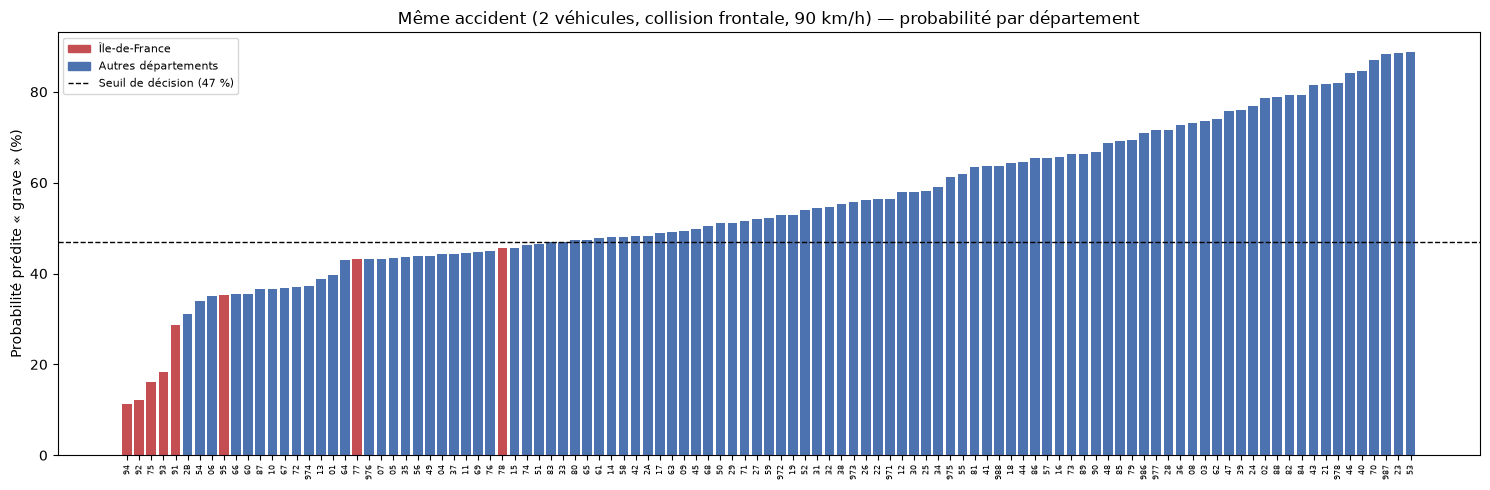

In [5]:
ILE_DE_FRANCE = {"75", "77", "78", "91", "92", "93", "94", "95"}

deps = [dep for dep, _ in results]
probs = [proba * 100 for _, proba in results]
colors = ["#C44E52" if dep in ILE_DE_FRANCE else "#4C72B0" for dep in deps]

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(deps, probs, color=colors, width=0.8)
threshold_line = ax.axhline(
    model.threshold * 100,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Seuil de décision ({model.threshold * 100:.0f} %)",
)
ax.set_xticks(range(len(deps)))
ax.set_xticklabels(deps, rotation=90, fontsize=6)
ax.set_ylabel("Probabilité prédite « grave » (%)")
ax.set_title("Même accident (2 véhicules, collision frontale, 90 km/h) — probabilité par département")
handles = [
    mpatches.Patch(color="#C44E52", label="Île-de-France"),
    mpatches.Patch(color="#4C72B0", label="Autres départements"),
    threshold_line,
]
ax.legend(handles=handles, loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig("notebooks/img/eval_ecart_departement.png", dpi=150)
plt.show()

## Interprétation

Les **5 départements les plus bas sont tous l'Île-de-France** (94, 92, 75, 93, 91), avant de
remonter progressivement vers la province : ce n'est pas une singularité parisienne, c'est un
**gradient urbain/rural systématique**.

## Ce que ça change, et ce qui reste ouvert

- **Confirme et quantifie** l'angle mort déjà documenté au CDC (§13.7/§14), avec un cas
  reproductible plutôt que la seule métrique agrégée (recall par département,
  cf. `eval_seuil_par_zone.ipynb`).
- **Ne propose pas de correctif** : la piste déjà explorée (seuil calibré par département)
  répare le recall local (0,777) mais fait chuter le F1 macro global sous le seuil CDC (0,609 au
  mieux, cf. `eval_enrichissement_vs_seuil.ipynb`) — **tension non résolue**, à arbitrer avant
  toute mise en production réelle, pas un réglage à improviser.
- Utile comme **argument de présentation** : montre une limite réelle du système, identifiée et
  quantifiée plutôt que découverte en direct devant un jury.